In [ ]:
import glob
import json
import pandas as pd
# ── Load All Results ──────────────────────────────────────────────────────────
# Reload from JSON files in case you're continuing after a Kaggle session restart.

def load_all_results(results_dir='/kaggle/input/datasets/hammaadrizwan/results'):
    records = []
    for f in glob.glob(f'{results_dir}/*.json'):
        with open(f) as fh:
            try:
                records.append(json.load(fh))
            except json.JSONDecodeError:
                pass
    return records,pd.DataFrame(records)

all_results,df = load_all_results()

In [ ]:
all_results

[{'model': 'MiniLM',
  'domain': 'laptop',
  'seed': 456,
  'accuracy': 0.7732,
  'macro_f1': 0.724,
  'n_params': '33M',
  'latency_ms_per_sample': 37.5325,
  'train_time_s': 910.879,
  'energy_kwh': 0.08201544,
  'carbon_kg_co2': 0.0191095968,
  'peak_memory_mb': 0.71},
 {'model': 'MiniLM',
  'domain': 'restaurant',
  'seed': 456,
  'accuracy': 0.7268,
  'macro_f1': 0.5324,
  'n_params': '33M',
  'latency_ms_per_sample': 39.8446,
  'train_time_s': 1519.996,
  'energy_kwh': 0.13686074,
  'carbon_kg_co2': 0.0318885521,
  'peak_memory_mb': 0.78},
 {'model': 'ALBERT',
  'domain': 'restaurant',
  'seed': 42,
  'accuracy': 0.7628,
  'macro_f1': 0.6717,
  'n_params': '12M',
  'latency_ms_per_sample': 158.2215,
  'train_time_s': 4432.785,
  'energy_kwh': 0.39913175,
  'carbon_kg_co2': 0.0929976968,
  'peak_memory_mb': 2.34},
 {'model': 'MiniLM',
  'domain': 'laptop',
  'seed': 123,
  'accuracy': 0.7559,
  'macro_f1': 0.7131,
  'n_params': '33M',
  'latency_ms_per_sample': 37.608,
  'train_ti

In [13]:
df=pd.DataFrame(all_results)
print(f'Loaded {len(df)} experiment results.')
print(f'Models: {df["model"].unique().tolist()}')
print(f'Domains: {df["domain"].unique().tolist()}')

Loaded 36 experiment results.
Models: ['TF-IDF+SVM', 'FastText', 'DistilBERT', 'ALBERT', 'MiniLM']
Domains: ['restaurant', 'laptop']


In [18]:
# ── Main Results Table (Table 2 in your paper) ────────────────────────────────
SEEDS   = [42, 123, 456]          # 3 seeds → enables paired t-tests
DOMAINS = ['restaurant', 'laptop']
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
METRICS = ['accuracy', 'macro_f1', 'energy_kwh', 'carbon_kg_co2',
           'train_time_s', 'peak_memory_mb', 'latency_ms_per_sample']

MODEL_ORDER = ['TF-IDF+SVM', 'FastText', 'DistilBERT', 'ALBERT', 'MiniLM']
import os

os.makedirs('results/aggregated', exist_ok=True)
def build_summary_table(df, domain):
    rows = []
    sub = df[df['domain'] == domain]
    for model in MODEL_ORDER:
        m = sub[sub['model'] == model]
        if m.empty: continue
        row = {'Model': model}
        for metric in METRICS:
            if metric in m.columns:
                row[f'{metric}_mean'] = round(m[metric].mean(), 6)
                row[f'{metric}_std']  = round(m[metric].std(),  6)
        rows.append(row)
    return pd.DataFrame(rows)

for domain in DOMAINS:
    print(f'\n{'='*60}')
    print(f'DOMAIN: {domain.upper()}')
    print(f'{'='*60}')
    summary = build_summary_table(df, domain)
    summary.to_csv(f'results/aggregated/summary_{domain}.csv', index=False)
    # Print readable version
    display_cols = ['Model', 'accuracy_mean', 'accuracy_std',
                    'macro_f1_mean', 'energy_kwh_mean', 'train_time_s_mean',
                    'peak_memory_mb_mean', 'latency_ms_per_sample_mean']
    avail = [c for c in display_cols if c in summary.columns]
    print(summary[avail].to_string(index=False))

print('\n✅ Summary tables saved to results/aggregated/')


DOMAIN: RESTAURANT
     Model  accuracy_mean  accuracy_std  macro_f1_mean  energy_kwh_mean  train_time_s_mean  peak_memory_mb_mean  latency_ms_per_sample_mean
TF-IDF+SVM       0.697600      0.000000       0.583200         0.000046           1.377333            12.383333                    0.053433
  FastText       0.693500      0.001400       0.597133         0.000047           1.414000             0.336667                    0.020267
DistilBERT       0.769300      0.004223       0.678500         0.119606        3481.222000             0.673333                  109.278400
    ALBERT       0.771633      0.015822       0.680167         0.398570        4426.553667             1.253333                  158.638033
    MiniLM       0.741100      0.012553       0.606100         0.135170        1501.218000             0.780000                   39.317333

DOMAIN: LAPTOP
     Model  accuracy_mean  accuracy_std  macro_f1_mean  energy_kwh_mean  train_time_s_mean  peak_memory_mb_mean  latency_ms_

In [24]:
# ── Statistical Analysis — Paired T-Tests + Bonferroni + Cohen's d ────────────

import os
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

# Ensure output directory exists (Kaggle-safe)
OUTPUT_DIR = '/kaggle/working/results/aggregated'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ── Effect Size: Cohen's d (paired version) ───────────────────────────────────
def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    diff = a - b
    return diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0.0


# ── Statistical Testing Function ──────────────────────────────────────────────
def run_statistical_tests(df, domain, metric='accuracy', id_col='seed'):
    """
    id_col = column that identifies paired runs (e.g., 'seed', 'run_id', 'fold')
    """

    sub = df[df['domain'] == domain]

    # ⚠️ Check if pairing column exists
    if id_col not in sub.columns:
        raise ValueError(
            f"Column '{id_col}' not found. Available columns: {list(sub.columns)}"
        )

    # Pivot: rows = seed/run, columns = model
    pivot = sub.pivot_table(
        index=id_col,
        columns='model',
        values=metric
    )

    # Keep only models present
    models = [m for m in MODEL_ORDER if m in pivot.columns]

    pairs = list(combinations(models, 2))
    n_comp = len(pairs)

    rows = []

    for m1, m2 in pairs:
        paired = pivot[[m1, m2]].dropna()

        # Need at least 2 paired samples
        if len(paired) < 2:
            continue

        a = paired[m1].values
        b = paired[m2].values

        t, p = stats.ttest_rel(a, b)
        p_bonf = min(p * n_comp, 1.0)
        d = cohens_d(a, b)

        rows.append({
            'Model A': m1,
            'Model B': m2,
            'n (paired)': len(paired),
            't-stat': round(t, 4),
            'p (raw)': round(p, 6),
            'p (Bonferroni)': round(p_bonf, 6),
            'Significant': '✓' if p_bonf < 0.05 else '✗',
            "Cohen's d": round(d, 4),
            'Effect': (
                'large' if abs(d) > 0.8 else
                'medium' if abs(d) > 0.5 else
                'small'
            ),
        })

    return pd.DataFrame(rows)


# ── Run for All Domains ───────────────────────────────────────────────────────
for domain in DOMAINS:
    print(f'\n--- Paired T-Tests on Accuracy | Domain: {domain.upper()} ---')

    try:
        ttest_df = run_statistical_tests(df, domain, metric='accuracy', id_col='seed')
        
        if ttest_df.empty:
            print("⚠️ Not enough paired samples for this domain.")
            continue

        print(ttest_df.to_string(index=False))

        # Save
        save_path = f'{OUTPUT_DIR}/ttests_{domain}.csv'
        ttest_df.to_csv(save_path, index=False)

    except Exception as e:
        print(f'❌ Error for domain {domain}: {e}')

print('\n✅ Statistical tests saved.')


--- Paired T-Tests on Accuracy | Domain: RESTAURANT ---
   Model A    Model B  n (paired)   t-stat  p (raw)  p (Bonferroni) Significant  Cohen's d Effect
TF-IDF+SVM   FastText           3   5.0724 0.036737        0.367374           ✗     2.9286  large
TF-IDF+SVM DistilBERT           3 -29.4106 0.001154        0.011541           ✓   -16.9802  large
TF-IDF+SVM     ALBERT           3  -7.2488 0.018504        0.185044           ✗    -4.1851  large
TF-IDF+SVM     MiniLM           3  -6.0022 0.026652        0.266524           ✗    -3.4654  large
  FastText DistilBERT           3 -37.7587 0.000701        0.007007           ✓   -21.8000  large
  FastText     ALBERT           3  -8.1756 0.014633        0.146335           ✗    -4.7202  large
  FastText     MiniLM           3  -6.0340 0.026383        0.263833           ✗    -3.4837  large
DistilBERT     ALBERT           3  -0.2960 0.795148        1.000000           ✗    -0.1709  small
DistilBERT     MiniLM           3   2.9200 0.100001        1.

In [26]:
# ── Pareto Frontier Identification ───────────────────────────────────────────

import os
import numpy as np
import pandas as pd

# Output directory (Kaggle-safe)
OUTPUT_DIR = '/kaggle/working/results/aggregated'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def find_pareto_optimal(df, domain, acc_col='accuracy', eng_col='energy_kwh'):
    sub = df[df['domain'] == domain].copy()

    # Drop missing values (important)
    sub = sub[[ 'model', acc_col, eng_col ]].dropna()

    # Mean performance per model
    means = sub.groupby('model')[[acc_col, eng_col]].mean().reset_index()

    pareto_flags = []

    for i, row in means.iterrows():
        dominated = False

        for j, other in means.iterrows():
            if i == j:
                continue

            # Check dominance condition
            if (
                (other[acc_col] >= row[acc_col]) and
                (other[eng_col] <= row[eng_col]) and
                (
                    (other[acc_col] > row[acc_col]) or
                    (other[eng_col] < row[eng_col])
                )
            ):
                dominated = True
                break

        pareto_flags.append(not dominated)

    means['pareto_optimal'] = pareto_flags

    pareto_models = means[means['pareto_optimal']]['model'].tolist()

    return pareto_models, means


# ── Run for all domains ──────────────────────────────────────────────────────
for domain in DOMAINS:
    print(f'\n--- Pareto Analysis | Domain: {domain.upper()} ---')

    pareto_models, means_df = find_pareto_optimal(df, domain)

    if means_df.empty:
        print("⚠️ No data available.")
        continue

    print(f'Pareto-Optimal Models: {pareto_models}')
    print(means_df[['model', 'accuracy', 'energy_kwh', 'pareto_optimal']].to_string(index=False))

    # Save results
    save_path = f'{OUTPUT_DIR}/pareto_{domain}.csv'
    means_df.to_csv(save_path, index=False)

print('\n✅ Pareto analysis saved.')


--- Pareto Analysis | Domain: RESTAURANT ---
Pareto-Optimal Models: ['ALBERT', 'DistilBERT', 'TF-IDF+SVM']
     model  accuracy  energy_kwh  pareto_optimal
    ALBERT  0.771633    0.398570            True
DistilBERT  0.769300    0.119606            True
  FastText  0.693500    0.000047           False
    MiniLM  0.741100    0.135170           False
TF-IDF+SVM  0.697600    0.000046            True

--- Pareto Analysis | Domain: LAPTOP ---
Pareto-Optimal Models: ['ALBERT', 'DistilBERT', 'TF-IDF+SVM']
     model  accuracy  energy_kwh  pareto_optimal
    ALBERT  0.794800    0.260817            True
DistilBERT  0.767467    0.077410            True
  FastText  0.701233    0.000040           False
    MiniLM  0.760967    0.085618           False
TF-IDF+SVM  0.712700    0.000034            True

✅ Pareto analysis saved.


In [28]:
# ── Seaborn Version ──────────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = '/kaggle/working/results/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", font="DejaVu Sans")

def plot_energy_accuracy_seaborn(df, domain):
    sub = df[df['domain'] == domain]

    means = sub.groupby('model')[['accuracy', 'energy_kwh']].mean().reset_index()
    stds  = sub.groupby('model')[['accuracy', 'energy_kwh']].std().reset_index()

    merged = means.merge(stds, on='model', suffixes=('', '_std'))

    pareto_models, _ = find_pareto_optimal(df, domain)
    merged['pareto'] = merged['model'].isin(pareto_models)

    # Convert units
    merged['energy_mwh'] = merged['energy_kwh'] * 1000
    merged['accuracy_pct'] = merged['accuracy'] * 100

    plt.figure(figsize=(7, 5))

    ax = sns.scatterplot(
        data=merged,
        x='energy_mwh',
        y='accuracy_pct',
        hue='model',
        style='model',
        s=180,
        edgecolor='black'
    )

    # Error bars
    for _, row in merged.iterrows():
        plt.errorbar(
            row['energy_mwh'],
            row['accuracy_pct'],
            xerr=row['energy_kwh_std'] * 1000,
            yerr=row['accuracy_std'] * 100,
            fmt='none',
            alpha=0.4
        )

    # Highlight Pareto points
    pareto_df = merged[merged['pareto']]
    plt.scatter(
        pareto_df['energy_mwh'],
        pareto_df['accuracy_pct'],
        s=260,
        facecolors='none',
        edgecolors='black',
        linewidths=2,
        label='Pareto Optimal'
    )

    # Pareto line
    pareto_pts = sorted(
        zip(pareto_df['energy_mwh'], pareto_df['accuracy_pct']),
        key=lambda x: x[0]
    )
    if len(pareto_pts) >= 2:
        px, py = zip(*pareto_pts)
        plt.plot(px, py, linestyle='--', linewidth=1.5, color='black')

    # Labels
    plt.xscale('log')
    plt.xlabel('Training Energy (mWh) [log scale]')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Energy–Accuracy Trade-off ({domain})')

    plt.tight_layout()

    # Save
    for ext in ['png', 'pdf']:
        plt.savefig(f'{OUTPUT_DIR}/fig1_{domain}.{ext}', dpi=300)

    plt.show()

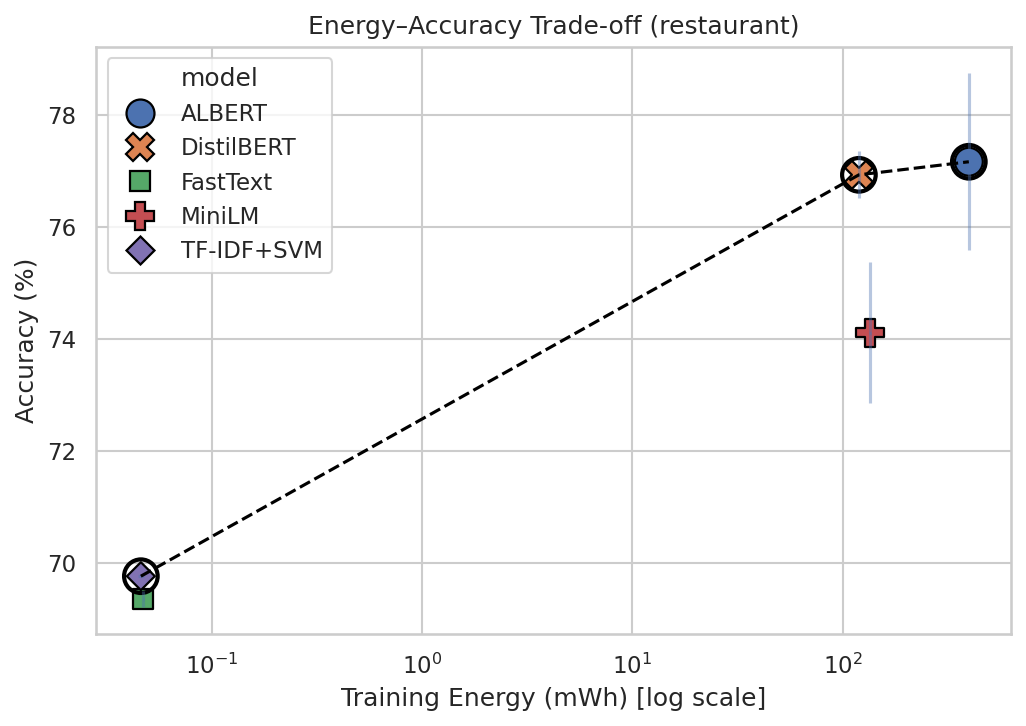

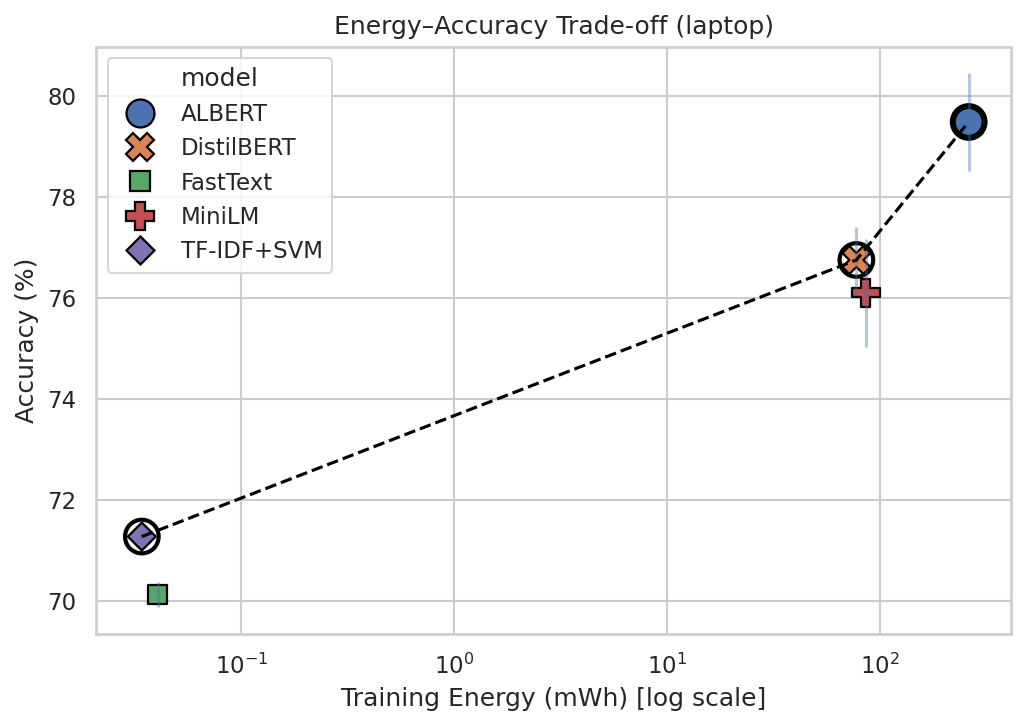

In [29]:
for domain in DOMAINS:
    plot_energy_accuracy_seaborn(df, domain)

In [30]:
# ── Figure 2 (Seaborn) ───────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = '/kaggle/working/results/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", font="DejaVu Sans")

def plot_cost_comparison_seaborn(df):
    metrics = {
        'Train Time (s)': 'train_time_s',
        'Peak Memory (MB)': 'peak_memory_mb',
        'Latency (ms/sample)': 'latency_ms_per_sample',
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        'Computational Cost Comparison Across Model Architectures',
        fontsize=13, fontweight='bold'
    )

    for ax, (label, col) in zip(axes, metrics.items()):
        if col not in df.columns:
            ax.set_visible(False)
            continue

        sub = df[['model', col]].dropna()

        # Order models consistently
        order = [m for m in MODEL_ORDER if m in sub['model'].unique()]

        # Barplot with error bars (Seaborn handles CI nicely)
        sns.barplot(
            data=sub,
            x='model',
            y=col,
            order=order,
            ax=ax,
            palette=MODEL_COLORS,
            errorbar='sd'
        )

        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(label, fontsize=10)
        ax.tick_params(axis='x', rotation=30)

        # Add value labels
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', fontsize=8)

    plt.tight_layout()

    # Save
    for ext in ['png', 'pdf']:
        plt.savefig(f'{OUTPUT_DIR}/fig2_cost_comparison.{ext}', dpi=300)

    plt.show()

/tmp/ipykernel_55/1045614217.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/1045614217.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/1045614217.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


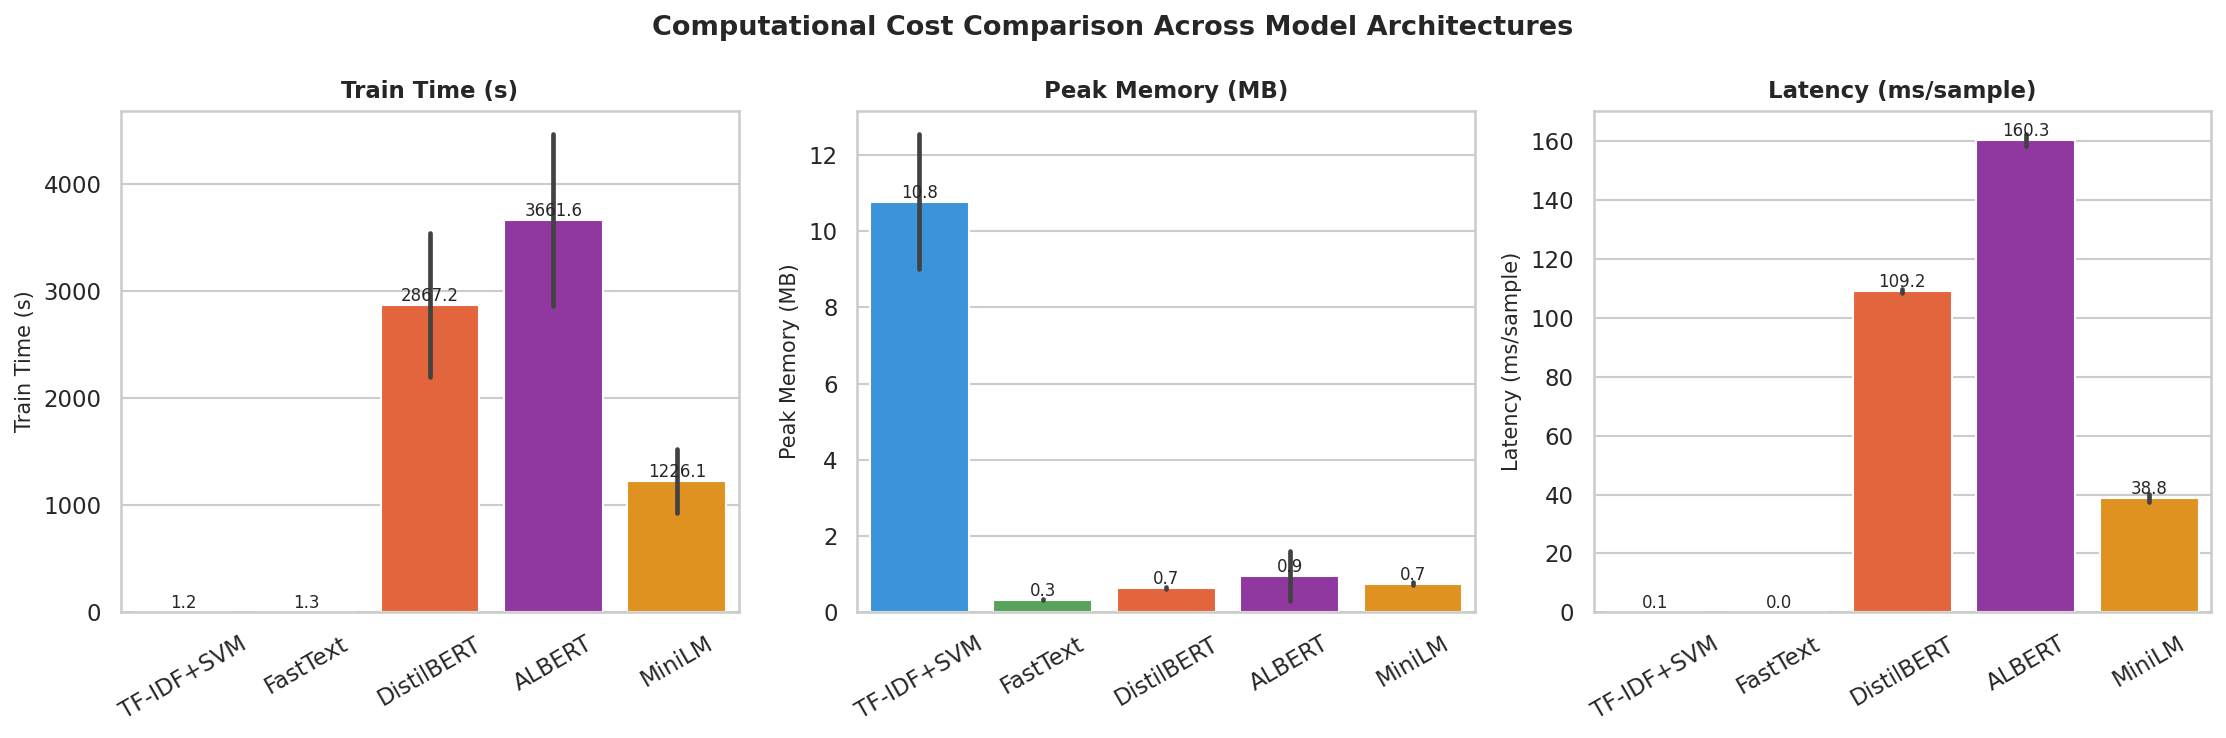

In [31]:
plot_cost_comparison_seaborn(df)

In [32]:
# ── Figure 3 (Seaborn) ───────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = '/kaggle/working/results/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", font="DejaVu Sans")

def plot_accuracy_comparison_seaborn(df):
    sub = df[['model', 'domain', 'accuracy']].dropna()

    # Convert to percentage
    sub['accuracy_pct'] = sub['accuracy'] * 100

    # Ensure consistent order
    sub['model'] = pd.Categorical(sub['model'], categories=MODEL_ORDER, ordered=True)

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=sub,
        x='model',
        y='accuracy_pct',
        hue='domain',
        palette={
            'restaurant': '#2196F3',
            'laptop': '#FF9800'
        },
        errorbar='sd'
    )

    ax.set_title(
        'Accuracy by Model and Domain — SemEval-2014',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(60, 100)

    plt.xticks(rotation=25)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=8)

    plt.legend(title='Domain')

    plt.tight_layout()

    # Save
    for ext in ['png', 'pdf']:
        plt.savefig(f'{OUTPUT_DIR}/fig3_accuracy_comparison.{ext}', dpi=300)

    plt.show()

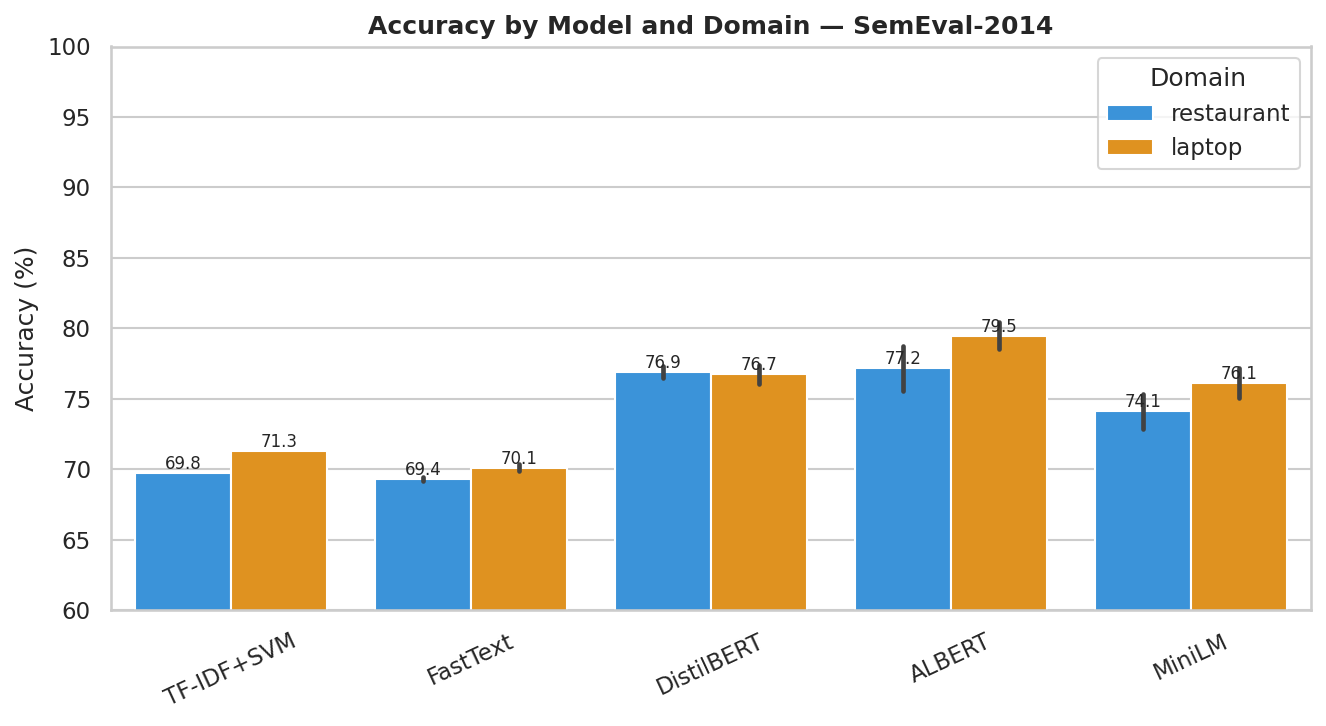

In [33]:
plot_accuracy_comparison_seaborn(df)

In [34]:
# ── Figure 4: Efficiency Heatmap (Seaborn) ───────────────────────────────────

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

OUTPUT_DIR = '/kaggle/working/results/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="white")

def plot_efficiency_heatmap(df):
    metric_cols = ['accuracy', 'macro_f1', 'energy_kwh',
                   'train_time_s', 'peak_memory_mb']
    avail = [c for c in metric_cols if c in df.columns]

    if 'energy_kwh' not in avail:
        print("⚠️ Energy column missing — heatmap skipped.")
        return

    fig, axes = plt.subplots(1, len(DOMAINS),
                             figsize=(6 * len(DOMAINS), 5),
                             sharey=True)

    if len(DOMAINS) == 1:
        axes = [axes]

    for ax, domain in zip(axes, DOMAINS):
        sub = df[df['domain'] == domain]
        means = sub.groupby('model')[avail].mean().reindex(MODEL_ORDER)

        # Normalize columns (0–1)
        m = means.copy()
        for col in avail:
            col_min = m[col].min()
            col_max = m[col].max()
            rng = col_max - col_min

            if rng > 0:
                m[col] = (m[col] - col_min) / rng
            else:
                m[col] = 0.0

            # Invert cost metrics
            if col in ['energy_kwh', 'train_time_s', 'peak_memory_mb']:
                m[col] = 1 - m[col]

        sns.heatmap(
            m,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            cbar=(ax == axes[-1]),  # single colorbar
            cbar_kws={'label': 'Normalised Score (higher = better)'}
        )

        ax.set_title(f'{domain.capitalize()}',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Model')

    plt.suptitle('Normalised Performance–Efficiency Heatmap',
                 fontsize=13, fontweight='bold')

    plt.tight_layout()

    for ext in ['png', 'pdf']:
        plt.savefig(f'{OUTPUT_DIR}/fig4_efficiency_heatmap.{ext}',
                    dpi=300, bbox_inches='tight')

    plt.show()

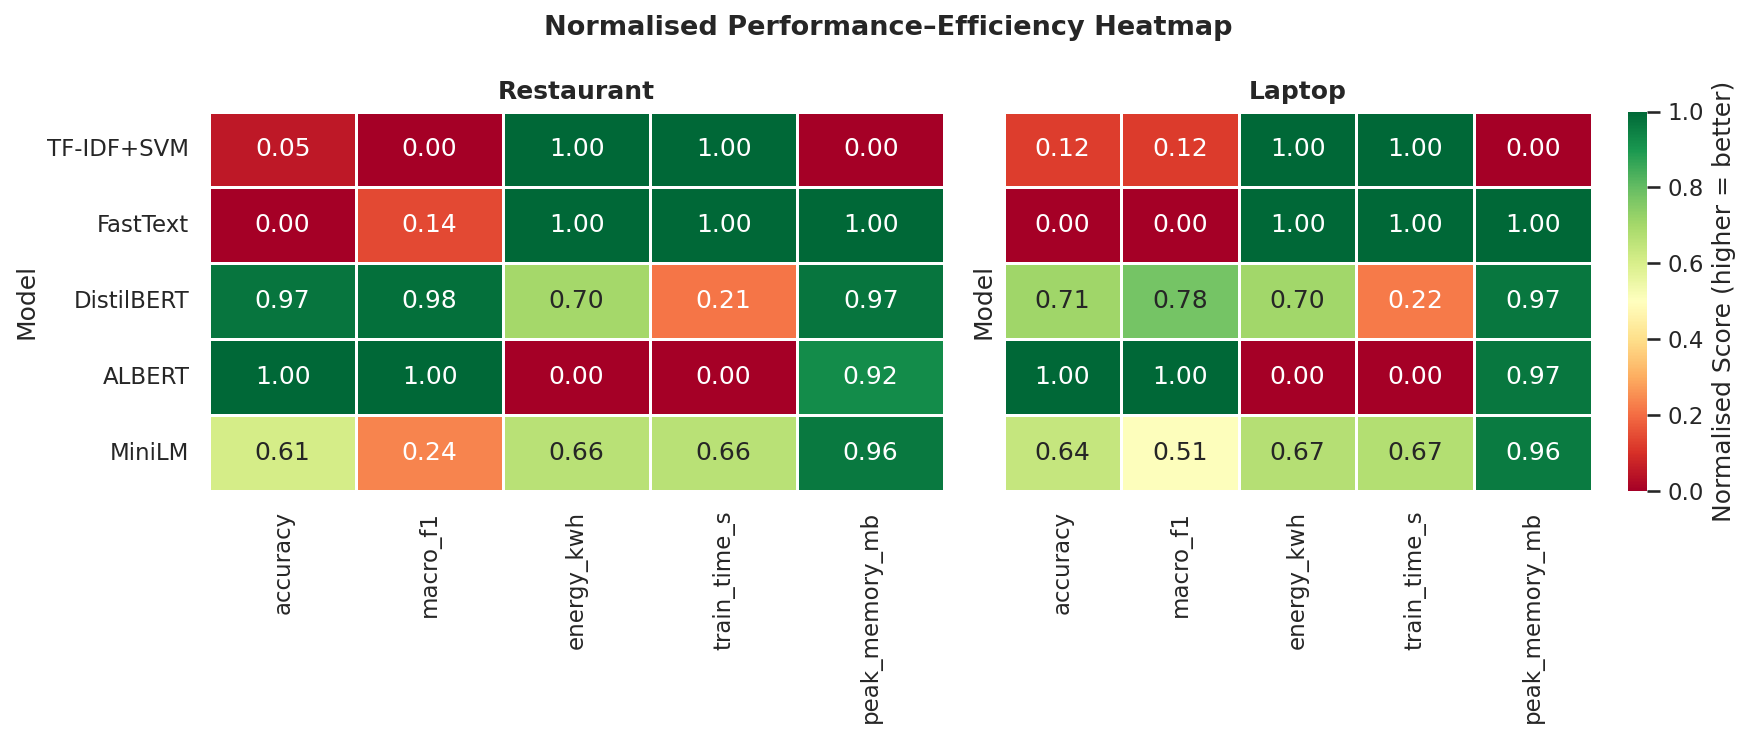

In [35]:
plot_efficiency_heatmap(df)

In [36]:
# ── Export Master CSV + Paper-Ready Table ─────────────────────────────────────

# Full raw results
df.to_csv('results/all_results.csv', index=False)

# Paper-ready Table 2 (mean ± std, both domains side by side)
paper_rows = []
for model in MODEL_ORDER:
    row = {'Model': model}
    for domain in DOMAINS:
        sub = df[(df['model'] == model) & (df['domain'] == domain)]
        if sub.empty: continue
        for metric in ['accuracy', 'macro_f1', 'energy_kwh', 'latency_ms_per_sample']:
            if metric in sub.columns:
                mu  = sub[metric].mean()
                std = sub[metric].std()
                row[f'{domain}_{metric}'] = f'{mu:.4f} ± {std:.4f}'
    paper_rows.append(row)

paper_table = pd.DataFrame(paper_rows)
paper_table.to_csv('results/aggregated/paper_table2.csv', index=False)

print('Exported files:')
print('  results/all_results.csv          ← all 30 raw runs')
print('  results/aggregated/summary_*.csv  ← per-domain summaries')
print('  results/aggregated/ttests_*.csv   ← statistical test results')
print('  results/aggregated/paper_table2.csv ← ready for your paper')
print('  figures/*.pdf + *.png            ← 4 publication figures')
print()
print('Paper Table 2 Preview:')
print(paper_table.to_string(index=False))

Exported files:
  results/all_results.csv          ← all 30 raw runs
  results/aggregated/summary_*.csv  ← per-domain summaries
  results/aggregated/ttests_*.csv   ← statistical test results
  results/aggregated/paper_table2.csv ← ready for your paper
  figures/*.pdf + *.png            ← 4 publication figures

Paper Table 2 Preview:
     Model restaurant_accuracy restaurant_macro_f1 restaurant_energy_kwh restaurant_latency_ms_per_sample laptop_accuracy laptop_macro_f1 laptop_energy_kwh laptop_latency_ms_per_sample
TF-IDF+SVM     0.6976 ± 0.0000     0.5832 ± 0.0000       0.0000 ± 0.0000                  0.0534 ± 0.0008 0.7127 ± 0.0000 0.6791 ± 0.0000   0.0000 ± 0.0000              0.0566 ± 0.0031
  FastText     0.6935 ± 0.0014     0.5971 ± 0.0018       0.0000 ± 0.0000                  0.0203 ± 0.0019 0.7012 ± 0.0025 0.6688 ± 0.0018   0.0000 ± 0.0000              0.0248 ± 0.0039
DistilBERT     0.7693 ± 0.0042     0.6785 ± 0.0092       0.1196 ± 0.0016                109.2784 ± 0.8360 0.76

In [38]:
import shutil
import os

# Zip results folder
shutil.make_archive(
    'sem_eval_outputs',
    'zip',
    '/kaggle/working',
    'results'
)

# Zip figures folder (correct path)
shutil.make_archive(
    'sem_eval_figures',
    'zip',
    '/kaggle/working/results',
    'figures'
)

print("✅ Download ready:")
print("/kaggle/working/sem_eval_outputs.zip")
print("/kaggle/working/sem_eval_figures.zip")

✅ Download ready:
/kaggle/working/sem_eval_outputs.zip
/kaggle/working/sem_eval_figures.zip
